# **Intro to XGBoost**



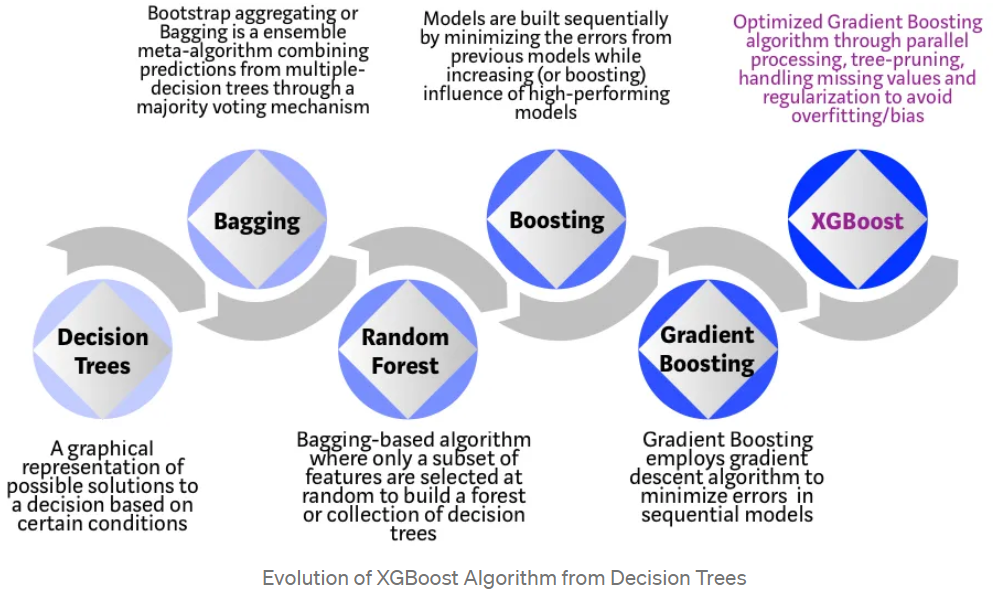

**AdaBoost**

La matematica de estos algoritmos es muy compleja, para entender mejor como funciona, recomiendo investigar el funcionamiento del AdaBoost, que fue el primer algoritmo de Boosting que salio. XGBoost es una mejora del Adaboost, y el CatBoost es una mejora del algoritmo XGBoost.

**Funcionamiento de XGBoost**

1. **Árboles de Decisión:**  
   XGBoost se basa en la construcción de árboles de decisión. Estos árboles son la base sobre la cual se construyen modelos más complejos.

2. **Bagging (Bootstrap Aggregation):**  
   Inicialmente, se generan múltiples árboles de decisión entrenándolos sobre subconjuntos aleatorios de los datos. Luego, se combinan sus predicciones mediante un mecanismo de votación para obtener un resultado más estable y robusto.

3. **Random Forest Mejorado:**  
   A partir de la idea del bagging, se construye un ensamble de árboles (Random Forest). Sin embargo, en este contexto no se limita únicamente a una votación simple: se aprovecha la diversidad de los árboles, de modo que algunos se desempeñen mejor en ciertos subconjuntos de datos y otros en diferentes situaciones, contribuyendo a un modelo global más preciso.

4. **Boosting:**  
   A diferencia de un Random Forest, en el boosting los árboles se entrenan de forma secuencial en lugar de paralela.  
   - **Boosting:** Se construyen modelos de forma secuencial, donde cada nuevo árbol se enfoca en corregir los errores de los anteriores.  

5. **Gradient Boosting:** Esta técnica optimiza el proceso de corrección de errores mediante el uso de gradientes, es decir, cada árbol se crea para minimizar la función de pérdida residual del conjunto de árboles ya entrenados.




**Valores SHAP**

XGBoost integra de forma nativa la capacidad de calcular valores SHAP a través de su implementación del algoritmo Tree SHAP. Esto se consigue utilizando el método predict con el parámetro **pred_contribs=True**, lo que devuelve la contribución de cada característica en la predicción del modelo.

**Rendimiento**

XGBoost es especialmente conocido por su rendimiento en competiciones de ciencia de datos y es ampliamente utilizado en la industria debido a su eficiencia y efectividad.

**Referencias**

This is a complex method. The explanation of the algorithm is out of the scope of this brief intro. We will explain just how to use the package utilities to get a working model.

For a small intro on **XGBoost** check:

- https://towardsdatascience.com/https-medium-com-vishalmorde-xgboost-algorithm-long-she-may-rein-edd9f99be63d
- https://towardsdatascience.com/getting-started-with-xgboost-in-scikit-learn-f69f5f470a97
- https://www.datacamp.com/community/tutorials/xgboost-in-python
- https://www.kaggle.com/stuarthallows/using-xgboost-with-scikit-learn

The base of the Boosting algorithms is however simple. Check **AdaBoost** (`sklearn.ensemble.AdaBoostClassifier`) to know one of the first boosting algorithms. AdaBoost has just 4 hyperparameters, so it is really easy to tune and understand, instead of the tens of parameters in XGBoost.


### **BONUS: Best algorithm for tabular data: CatBoost (as of feb-2021)**

If you want to go straitgh to the real high end of ML algorithms for tabular data (as of feb-2021), take a look al CatBoost:

https://affine.medium.com/catboost-a-new-game-of-machine-learning-72a7dcea0ac4

https://towardsdatascience.com/catboost-demystified-8b0b538bfa31

https://www.youtube.com/watch?v=mUGAA02fGuw&ab_channel=BhaveshBhatt





## **XGBoost for Regression**

En este apartado vamos a utilizar **XGBoost en un problema de regresión**. Recordemos que un problema de regresión es aquel en el que la variable objetivo es **numérica continua**, es decir, queremos predecir un valor y no una clase.

En este ejemplo se trabaja con el conocido **dataset de Boston**, en el que el objetivo es predecir el valor de las viviendas a partir de diferentes características del entorno y de la vivienda.

El flujo que seguiremos será el habitual en Machine Learning:

1. Cargar el dataset
2. Preparar los datos
3. Dividir en entrenamiento y prueba
4. Entrenar el modelo XGBoost
5. Realizar predicciones
6. Evaluar el error del modelo
7. Interpretar el modelo con SHAP

La idea es que el alumno entienda no solo cómo entrenar un modelo, sino también cómo evaluar su rendimiento y cómo empezar a interpretar qué variables están influyendo en las predicciones.

### **Load dataset**

In [ ]:
from sklearn.datasets import fetch_openml
# Cargar el dataset Boston desde OpenML
dataset = fetch_openml(name='boston', version=1, as_frame=True)

In [ ]:
print(dataset.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

In [ ]:
print(dataset.data.shape)
print(dataset.target.shape)

(506, 13)
(506,)


### **Optional: Convert to dataframe for better readability**

En este paso convertimos el dataset a un **DataFrame de pandas**.

Aunque los datos ya están cargados en memoria, trabajar con un DataFrame facilita mucho la lectura y el análisis, ya que los datos se organizan en forma de **tabla con columnas y filas**, donde cada columna representa una variable.

Además, asignaremos nombres a las columnas para identificar claramente qué representa cada característica del dataset.

In [ ]:
# Convertimos las variables de entrada del dataset en un DataFrame
# dataset.data contiene todas las características del dataset
df_features = pd.DataFrame(data=dataset.data)

# Convertimos la variable objetivo en otro DataFrame
# dataset.target contiene el valor que queremos predecir
df_target = pd.DataFrame(dataset.target)

# Unimos las variables de entrada y la variable objetivo en una sola tabla
# axis=1 indica que la unión se hace por columnas
df = pd.concat([df_features, df_target], axis=1)

# Asignamos nombres a las columnas para que sea más fácil identificar cada variable
df.columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
    'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### **Preprocess dataset**

Antes de entrenar cualquier modelo de Machine Learning es necesario preparar los datos.

En este paso vamos a:

1. Separar las variables del dataset en **variables de entrada (features)** y **variable objetivo (target)**.
2. Dividir los datos en **conjunto de entrenamiento** y **conjunto de prueba**.

El conjunto de entrenamiento se utilizará para que el modelo aprenda los patrones de los datos, mientras que el conjunto de prueba se utilizará posteriormente para evaluar qué tan bien funciona el modelo con datos que no ha visto durante el entrenamiento.

In [ ]:
# split in features and target
X = dataset.data
y = dataset.target

In [ ]:
from sklearn.model_selection import train_test_split
#Split in train and test subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### **Define and fit XGBoost model**

En este paso vamos a crear y entrenar un modelo de **XGBoost para regresión**.

XGBoost es un algoritmo basado en **Gradient Boosting**, que funciona construyendo múltiples árboles de decisión de forma secuencial. Cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores.

Este enfoque suele producir modelos muy potentes y es ampliamente utilizado en problemas reales de Machine Learning.

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", enable_categorical=True, random_state=1)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### **Make predictions and evaluate model**

Una vez entrenado el modelo, el siguiente paso es utilizarlo para hacer predicciones sobre el conjunto de prueba.

Después compararemos esas predicciones con los valores reales mediante una métrica de error. En este caso utilizaremos el **RMSE** (*Root Mean Squared Error*), que nos indica, de forma aproximada, cuánto se equivoca el modelo al predecir.

Finalmente, empezaremos a interpretar el modelo con **SHAP**, una técnica que nos ayuda a entender cuánto aporta cada variable a una predicción concreta.

In [ ]:
# Utilizamos el modelo entrenado para predecir los valores del conjunto de prueba
# X_test contiene datos que el modelo no ha visto durante el entrenamiento
y_pred = xgb_model.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(y_test, y_pred)
print(np.sqrt(mse))

2.845164694900871


El valor obtenido es el **RMSE** del modelo, aproximadamente **2.85**.

Esto significa que, en promedio, las predicciones del modelo se desvían unos **2.85 puntos** respecto al valor real de la variable objetivo.

En general, cuanto menor sea este valor, mejor será el comportamiento del modelo. Por tanto, esta métrica nos permite tener una medida cuantitativa del error de predicción.

In [ ]:
print(xgb.__version__)

3.2.0


In [ ]:
# Obtener los valores SHAP (Tree SHAP) para el conjunto de prueba
# El último valor de cada fila corresponde al término de sesgo (bias)
# Convertir X_test a DMatrix, que es requerido por Booster.predict
dtest = xgb.DMatrix(X_test, enable_categorical=True)
shap_values = xgb_model.get_booster().predict(dtest, pred_contribs=True)
print("Shape de los valores SHAP:", shap_values.shape)

Shape de los valores SHAP: (102, 14)


+Comentar resultado (evaluar)

### Interpretación del modelo con SHAP

Hasta ahora hemos visto cómo entrenar y evaluar el modelo, pero todavía no sabemos con claridad **qué variables están influyendo en sus predicciones**.

Para analizar esto utilizamos **SHAP**, una técnica de interpretabilidad que permite medir la contribución de cada variable a una predicción.

En este bloque vamos a calcular los valores SHAP para el conjunto de prueba. Así podremos ver cuántas contribuciones se generan y empezar a interpretar una instancia concreta.

En este bloque mostramos los **valores SHAP correspondientes a la primera instancia del conjunto de prueba**.

Los valores SHAP representan la **contribución de cada variable del modelo a la predicción final**.

Cada número indica cuánto está empujando esa variable la predicción:

- **Valores positivos** → aumentan la predicción
- **Valores negativos** → reducen la predicción

De esta forma podemos empezar a entender **qué variables están influyendo más en la predicción del modelo para una observación concreta**.

In [ ]:
# Mostrar los valores SHAP de la primera instancia del conjunto de prueba
print("Valores SHAP para la primera instancia:")
print(shap_values[0])

Valores SHAP para la primera instancia:
[[ 3.2152876e-01 -1.1288311e-02  0.0000000e+00  9.7416088e-02
   3.2299597e-02  2.6012352e-04  8.4298533e-01  0.0000000e+00
   9.8920865e-03  5.4638065e-02  2.3091588e-02  0.0000000e+00
   2.0506196e+00 -1.6952473e-01]
 [-4.2285830e-01  6.1783452e-02  1.7565276e-02  0.0000000e+00
  -1.8379819e-01  0.0000000e+00  5.2731410e-03 -1.8974658e-02
   0.0000000e+00 -2.2463658e+00 -7.5762630e-02  0.0000000e+00
  -4.7087449e-01  3.1007737e-01]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00 -2.1055319e+00 -2.1511450e-02
  -9.7519206e-03  1.0781943e-01 -1.9913831e-01 -5.5101520e-01
   0.0000000e+00 -1.8385507e-01]]


Gráfico

La matriz que aparece muestra las **contribuciones SHAP de cada variable para esa instancia**.

Cada posición representa el impacto que tiene una característica del dataset en la predicción del modelo.

En este caso vemos muchos valores cercanos a cero, lo que indica que algunas variables tienen **muy poca influencia en la predicción**, mientras que otras tienen valores más altos y por tanto **influyen más en el resultado final**.

Esta información es útil para interpretar el modelo y entender **cómo está tomando sus decisiones**.

En el siguiente bloque calculamos los valores SHAP utilizando el modelo entrenado.

Primero convertimos el conjunto de prueba (`X_test`) al formato **DMatrix**, que es el formato interno optimizado que utiliza XGBoost para realizar predicciones de forma más eficiente.

Después utilizamos el booster interno del modelo para calcular los valores SHAP, indicando `pred_contribs=True`. Esto hace que el modelo devuelva **la contribución de cada variable a la predicción**, en lugar de devolver solo el valor predicho.

In [ ]:
 # Obtener los valores SHAP (Tree SHAP) para el conjunto de prueba
# El último valor de cada fila corresponde al término de sesgo (bias)

# Convertimos X_test a DMatrix, que es el formato interno optimizado de XGBoost
# enable_categorical=True permite trabajar con variables categóricas si existen
dtest = xgb.DMatrix(X_test, enable_categorical=True)

# Calculamos los valores SHAP usando el booster interno del modelo
# pred_contribs=True hace que la salida sea la contribución de cada variable a la predicción
shap_values = xgb_model.get_booster().predict(dtest, pred_contribs=True)

# Mostramos la forma de la matriz de valores SHAP
print("Shape de los valores SHAP:", shap_values.shape)

Shape de los valores SHAP: (36, 3, 14)


La forma `(36, 3, 14)` indica la estructura de los valores SHAP calculados.

Esto significa que:

- **36** corresponde al número de observaciones del conjunto de prueba.
- **3** corresponde al número de clases que el modelo está considerando.
- **14** corresponde al número de contribuciones por predicción.

Estas contribuciones incluyen las variables del modelo más un valor adicional llamado **bias o valor base**, que representa la predicción inicial del modelo antes de considerar las características de cada instancia.

### Separación de contribuciones de las variables y del valor base

En el paso anterior calculamos los valores SHAP para el conjunto de prueba.  
Ahora vamos a separar dos elementos importantes de esos valores:

- **Las contribuciones de cada variable del modelo**
- **El término de sesgo o valor base (bias)**

El valor base representa la predicción inicial del modelo antes de considerar la información de las variables de una observación concreta. A partir de ese valor base, cada variable suma o resta contribución hasta llegar a la predicción final.

In [ ]:
# Opcional: Separar contribuciones de características y el bias
contrib_features = shap_values[:, :-1]
bias_term = shap_values[:, -1]
print("\nPrimeras contribuciones de características para la primera instancia:")
print(contrib_features[0])
print("Bias (término de sesgo) (valor base) para la primera instancia:")
print(bias_term[0])
# el valor base se inicializa como la media de la variable objetivo (y) del conjunto de entrenamiento.
# Es decir, es la predicción que se haría si no se dispusiera de ninguna información adicional de las características


Primeras contribuciones de características para la primera instancia:
[ 0.03004759 -0.05999527  1.1113158  -0.02880627  0.5374531  -0.03847497
 -0.6029896   0.17349933 -0.20307997  0.7012127   0.02484092 -0.2374566
  3.4198754 ]
Bias (término de sesgo) (valor base) para la primera instancia:
22.522253


En esta salida se muestran dos elementos importantes de la predicción:

**Contribuciones de las variables**

Los valores que aparecen en el primer vector representan cuánto está contribuyendo cada variable a la predicción final.

- Valores **positivos** → aumentan la predicción
- Valores **negativos** → disminuyen la predicción

Cada número indica el impacto de una variable concreta del modelo en la predicción de esa instancia.

**Valor base (bias)**

El valor base es **22.522253**.

Este valor representa la predicción inicial del modelo antes de considerar las características de la observación. En otras palabras, es la predicción media del modelo basada únicamente en la información global del conjunto de entrenamiento.

A partir de este valor base, las contribuciones de las variables se suman o se restan para obtener la predicción final del modelo para esa instancia.

## **XGBoost for Binary Classification**

En este apartado vamos a aplicar **XGBoost a un problema de clasificación binaria**.

A diferencia del caso anterior de regresión, ahora la variable objetivo no es un valor numérico continuo, sino una **clase**. En un problema de clasificación binaria solo existen **dos posibles categorías**.

En este ejemplo utilizaremos el **dataset de cáncer de mama (Breast Cancer Dataset)** incluido en `scikit-learn`. El objetivo del modelo será clasificar los tumores en dos categorías: benignos o malignos.

El flujo de trabajo será similar al del apartado anterior:

1. Cargar el dataset
2. Separar variables de entrada y variable objetivo
3. Analizar las dimensiones del conjunto de datos
4. Entrenar el modelo de clasificación
5. Evaluar su rendimiento

### **Load dataset**

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target


In [ ]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


La salida nos indica el tamaño del dataset:

- `(569, 30)` significa que tenemos **569 observaciones** y **30 variables de entrada**.
- `(569,)` indica que tenemos **569 etiquetas de clase**, una para cada observación.

Esto confirma que cada muestra del dataset tiene 30 características asociadas y una variable objetivo que indica a qué clase pertenece.

In [ ]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

### **Preprocess dataset**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### **Define and fit a XGBoost model**

En este paso vamos a crear y entrenar un modelo de **XGBoost para clasificación binaria**.

XGBoost es un algoritmo basado en **árboles de decisión que se entrenan de forma secuencial**. Cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores, lo que permite construir modelos muy potentes.

En este caso utilizaremos la clase **XGBClassifier**, que está diseñada para resolver problemas de clasificación.

El objetivo del modelo será aprender a clasificar cada observación del dataset en una de las dos clases posibles.

In [ ]:
import xgboost as xgb


# Creamos el modelo XGBoost para clasificación
# objective="binary:logistic" indica que estamos resolviendo un problema de clasificación binaria
# random_state=1 fija la semilla para que el entrenamiento sea reproducible
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=1)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Importamos la función deepcopy de la librería copy
# deepcopy permite crear una copia completamente independiente de un objeto
from copy import deepcopy

# Creamos una copia del modelo XGBoost entrenado
# De esta forma podemos trabajar con esta copia sin alterar el modelo original
xgb_model_binary = deepcopy(xgb_model)

### **Make predictions and evaluate model**

Una vez entrenado el modelo, el siguiente paso es utilizarlo para **predecir la clase de nuevas observaciones**.

Después compararemos las predicciones del modelo con las clases reales del conjunto de prueba. Para evaluar el rendimiento utilizaremos varias métricas comunes en problemas de clasificación:

- **Matriz de confusión**
- **Precision**
- **Recall**
- **F1-score**
- **Accuracy**

Estas métricas nos permitirán entender qué tan bien está funcionando el modelo al clasificar las observaciones.

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(accuracy_score(y_test, y_pred))

[[45  2]
 [ 2 65]]
              precision    recall  f1-score   support

           0     0.9574    0.9574    0.9574        47
           1     0.9701    0.9701    0.9701        67

    accuracy                         0.9649       114
   macro avg     0.9638    0.9638    0.9638       114
weighted avg     0.9649    0.9649    0.9649       114

0.9649122807017544


La **accuracy del modelo es aproximadamente 0.9649**, lo que significa que el modelo clasifica correctamente alrededor del **96.5% de las observaciones del conjunto de prueba**.

Este valor indica que el modelo está funcionando bastante bien para este problema de clasificación.

## **XGBoost for Multiclass Classification**

En este apartado vamos a utilizar **XGBoost en un problema de clasificación multiclase**.

A diferencia de la clasificación binaria, donde solo existen dos posibles categorías, en la clasificación multiclase el modelo debe aprender a distinguir entre **tres o más clases diferentes**.

En este ejemplo trabajaremos con el **dataset del vino** incluido en `scikit-learn`. El objetivo será predecir a qué clase pertenece cada muestra de vino a partir de sus características químicas.

El proceso será similar al que hemos seguido en apartados anteriores:

1. Cargar el dataset
2. Separar las variables de entrada y la variable objetivo
3. Analizar las dimensiones de los datos
4. Entrenar un modelo de clasificación multiclase
5. Evaluar su rendimiento
6. Interpretar sus predicciones

### **Load dataset**

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target


In [ ]:
print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [ ]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

### **Preprocess dataset**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### **Define and fit a XGBoost model**

En este paso vamos a crear y entrenar un modelo **XGBoost para clasificación multiclase**.

En problemas de clasificación multiclase el modelo debe aprender a distinguir entre **más de dos clases posibles**. En este caso, el modelo aprenderá a clasificar cada muestra del dataset del vino en una de las clases disponibles.

Para ello utilizamos la clase **XGBClassifier**, indicando un objetivo específico para clasificación multiclase.

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=1)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

El parámetro `objective="multi:softprob"` indica que el modelo debe resolver un problema de **clasificación multiclase**.

Con este objetivo, el modelo calcula **la probabilidad de que cada observación pertenezca a cada una de las clases posibles**. Después, la clase con mayor probabilidad será la predicción final del modelo.

### **Make predictions and evaluate model**

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(accuracy_score(y_test, y_pred))

[[14  0  0]
 [ 1 14  1]
 [ 0  0  6]]
              precision    recall  f1-score   support

           0     0.9333    1.0000    0.9655        14
           1     1.0000    0.8750    0.9333        16
           2     0.8571    1.0000    0.9231         6

    accuracy                         0.9444        36
   macro avg     0.9302    0.9583    0.9406        36
weighted avg     0.9503    0.9444    0.9441        36

0.9444444444444444


La **accuracy del modelo es aproximadamente 0.944**, lo que significa que el modelo clasifica correctamente alrededor del **94.4% de las muestras del conjunto de prueba**.

Este resultado indica que el modelo tiene un buen rendimiento en este problema de clasificación multiclase.

### Importancia de las variables (Feature Importance)

Una vez entrenado el modelo, es interesante analizar **qué variables han tenido mayor influencia en las decisiones del modelo**.

XGBoost permite calcular automáticamente la **importancia de cada característica (feature importance)**. Esto nos ayuda a entender qué variables están siendo más relevantes para realizar las predicciones.

En este paso vamos a visualizar un gráfico que muestra la importancia relativa de cada variable utilizada por el modelo.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

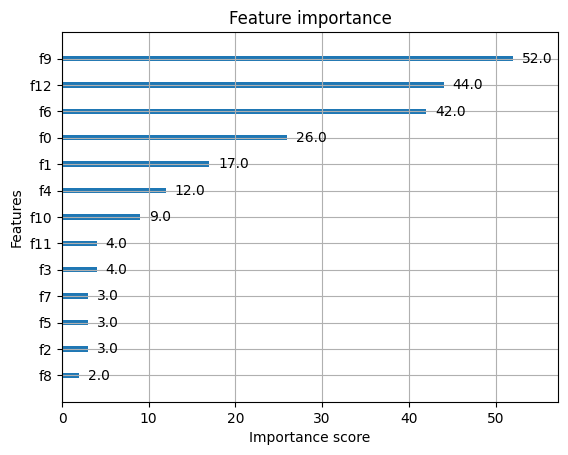

In [ ]:
xgb.plot_importance(xgb_model)

### Visualización de uno de los árboles del modelo XGBoost

XGBoost es un modelo basado en **conjuntos de árboles de decisión (ensemble de árboles)**.

En lugar de construir un único árbol, el algoritmo construye **muchos árboles pequeños** que trabajan conjuntamente para realizar las predicciones.

En este paso vamos a visualizar **uno de los árboles que forman parte del modelo**. Esto nos permite entender cómo el modelo toma decisiones a partir de las variables del dataset.

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

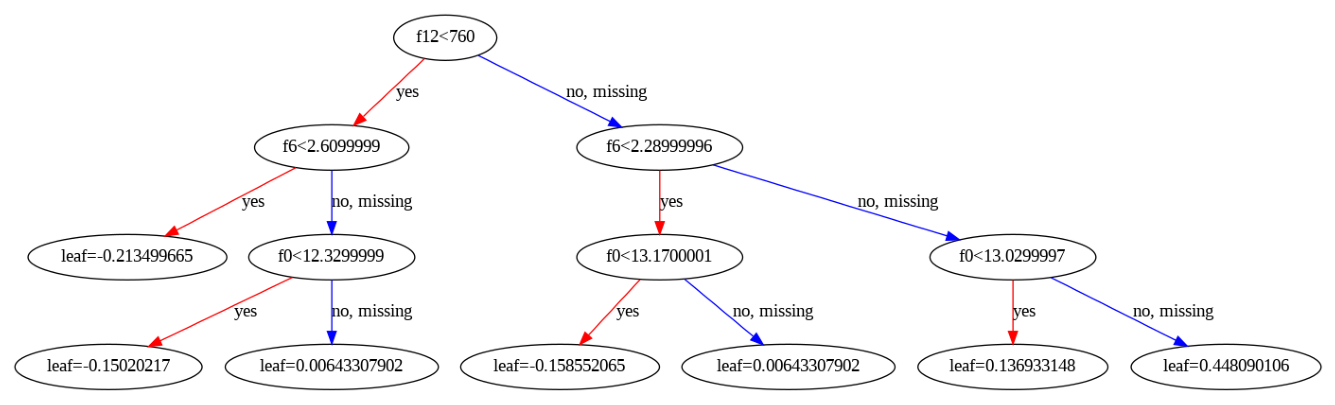

In [ ]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1,1, figsize=(20,5))

# Dibujamos uno de los árboles del modelo XGBoost
# num_trees=0 indica que queremos visualizar el primer árbol del modelo
xgb.plot_tree(booster=xgb_model, num_trees=0, ax=axis)

El gráfico muestra uno de los árboles de decisión que componen el modelo XGBoost.

Cada nodo del árbol representa una **condición sobre una variable**. Por ejemplo:

f12 < 760

Esto significa que el modelo está comprobando si el valor de la variable `f12` es menor que 760.

Dependiendo del resultado:

- si la condición se cumple → se sigue la rama izquierda
- si no se cumple → se sigue la rama derecha

Este proceso se repite en diferentes nodos hasta llegar a una **hoja (leaf)**.

Las hojas contienen un valor numérico que representa la **contribución de ese árbol a la predicción final**.

## **BONUS: Compute AUC ROC**

Además de métricas como **accuracy, precision o recall**, también podemos evaluar un modelo utilizando la métrica **ROC-AUC**.

ROC-AUC mide la capacidad del modelo para **distinguir correctamente entre las diferentes clases**.

Un valor de AUC cercano a:

- **1** → modelo muy bueno
- **0.5** → modelo equivalente al azar

En problemas de **clasificación multiclase**, el cálculo de ROC-AUC requiere un tratamiento especial, ya que existen más de dos clases posibles.

### **Compute `roc_auc_score`**

La función sklearn.metrics.roc_auc_score también puede utilizarse para clasificación multiclase:

- ovo (one-vs-one): calcula el AUC medio considerando todas las combinaciones posibles por pares entre clases.
- ovr (one-vs-rest): calcula el AUC de cada clase frente al resto de clases.

Para calcular AUC-ROC, necesitamos predecir las probabilidades de pertenecer a cada clase, no solo la clase asignada. Por lo tanto, debemos utilizar el método predict_proba (en lugar de predict).

### Predicción de probabilidades y cálculo de ROC-AUC

Para calcular la métrica **ROC-AUC** en problemas de clasificación multiclase no basta con predecir la clase final.

Necesitamos conocer **la probabilidad que el modelo asigna a cada clase** para cada observación.

Para ello utilizamos el método `predict_proba()`, que devuelve una matriz donde cada fila contiene las probabilidades de pertenecer a cada una de las clases.

In [ ]:
y_scores = xgb_model.predict_proba(X_test)


In [ ]:
print(y_scores.shape)
print(y_scores[0:3])

(36, 3)
[[0.9961344  0.00187391 0.00199168]
 [0.00597647 0.01300274 0.9810208 ]
 [0.02768974 0.9633253  0.00898489]]


El resultado `(36, 3)` indica que:

- tenemos **36 observaciones en el conjunto de prueba**
- el modelo predice **3 probabilidades para cada observación**, una por cada clase.

Cada fila corresponde a una observación y cada columna representa la probabilidad de pertenecer a una de las clases.

[0.9961344  0.00187391 0.00199168]

Esto significa que el modelo estima:

- **99.6 %** de probabilidad de pertenecer a la clase 0  
- **0.18 %** de probabilidad de pertenecer a la clase 1  
- **0.19 %** de probabilidad de pertenecer a la clase 2  

Por lo tanto, el modelo clasificaría esta observación como **clase 0**, ya que es la que tiene mayor probabilidad.

In [ ]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_scores, multi_class='ovr'))

0.9989583333333334


El valor obtenido es aproximadamente **0.99**, lo que indica que el modelo tiene una **excelente capacidad para distinguir entre las diferentes clases**.

Un valor de ROC-AUC cercano a **1** significa que el modelo clasifica correctamente la mayoría de las observaciones.

### **Plot ROC curves**

For an explanation on the intrepretation of ROC curves and AUC, you can check for example:

https://medium.com/hiredscore-engineering/7-things-you-should-know-about-roc-auc-b4389ea2b2e3

In [ ]:
# plot_roc_curve just works for binary classification, so, useless in this problem
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))

RocCurveDisplay.from_estimator(xgb_model_binary, X_test, y_test, ax=ax1)
plt.show()

ImportError: cannot import name 'plot_roc_curve' from 'sklearn.metrics' (/usr/local/lib/python3.12/dist-packages/sklearn/metrics/__init__.py)

Las curvas ROC se utilizan normalmente en problemas de clasificación binaria para analizar el comportamiento de un clasificador.

Para poder extender la curva ROC y el área ROC (AUC) a problemas de clasificación multietiqueta o multiclase, es necesario binarizar la salida del modelo.

In [ ]:
import pandas as pd

y_test_onehot = pd.get_dummies(y_test)
y_test_onehot.head()

,0,1,2
0,True,False,False
1,False,False,True
2,False,True,False
3,True,False,False
4,False,True,False


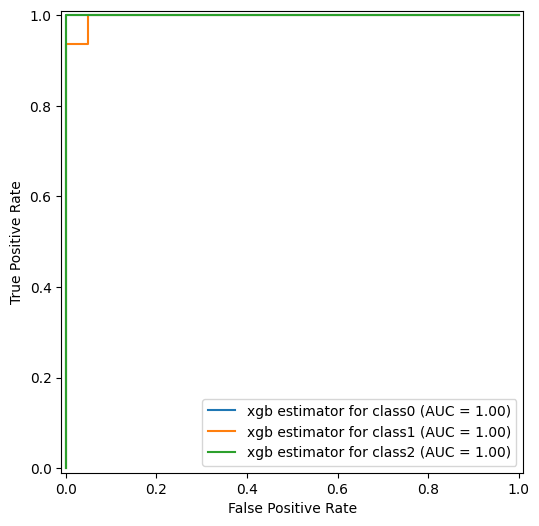

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, RocCurveDisplay, roc_curve

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))

# plot ROC for class0:
fpr, tpr, thresholds = roc_curve(y_test_onehot[0], y_scores[:,0]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class0')
display.plot(ax1)
# plot ROC for class1:
fpr, tpr, thresholds = roc_curve(y_test_onehot[1], y_scores[:,1]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class1')
display.plot(ax1)
# plot ROC for class2:
fpr, tpr, thresholds = roc_curve(y_test_onehot[2], y_scores[:,2]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class2')
display.plot(ax1)
# plt.show()

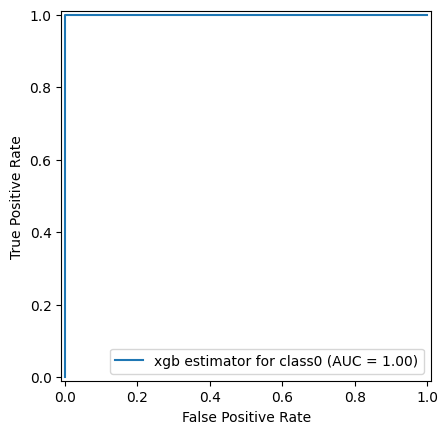

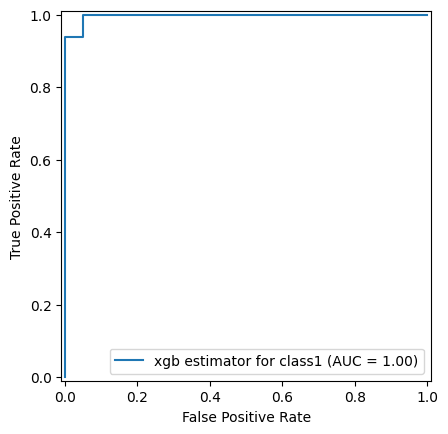

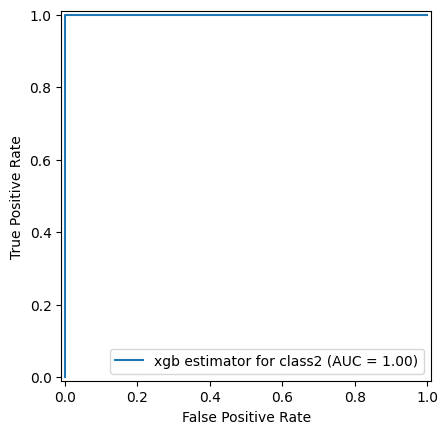

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_onehot[0], y_scores[:,0]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class0')
display.plot()
# plot ROC for class1:
fpr, tpr, thresholds = roc_curve(y_test_onehot[1], y_scores[:,1]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class1')
display.plot()
# plot ROC for class2:
fpr, tpr, thresholds = roc_curve(y_test_onehot[2], y_scores[:,2]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class2')
display.plot()